In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, roc_curve, auc


In [2]:
# 1. Load the dataset
print("Loading data...")
df = pd.read_csv('network_traffic.csv')

Loading data...


In [3]:
df.head()

,duration,src_bytes,dst_bytes,failed_logins,label
0,0.662167,135.936471,2293.142752,0.0,0.0
1,2.097548,158.268698,3554.091408,0.0,0.0
2,9.352428,6800.511182,54.200945,4.0,1.0
3,0.984261,157.331965,2237.237415,0.0,0.0
4,0.573478,179.598883,1979.132566,0.0,0.0


In [4]:
df.describe()

,duration,src_bytes,dst_bytes,failed_logins,label
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,8.459274,2558.882591,1543.478379,0.990000,0.50000
std,12.032900,2506.825053,1534.502857,1.417007,0.50025
min,0.010149,96.062267,23.642523,0.000000,0.00000
25%,1.107649,149.345812,50.743025,0.000000,0.00000
50%,3.308095,1096.032730,816.485748,0.000000,0.50000
75%,11.069575,4976.004171,3039.716866,2.000000,1.00000
max,96.082093,8137.748534,4289.854669,4.000000,1.00000


In [5]:
# Separate Features (X) from the Target Label (y)
X = df.drop('label', axis=1)
y = df['label']

In [6]:
# 2. Split the data (80% for training, 20% for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
# 3. Scale the features (CRITICAL for Neural Networks)
# This forces all features to have a mean of 0 and standard deviation of 1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
# 4. Build the 3-Layer Neural Network
model = Sequential([
    Input(shape=(4,)),                      # Layer 1: INPUT LAYER (4 features)
    Dense(16, activation='relu'),           # Layer 2: HIDDEN LAYER (16 neurons to find patterns)
    Dense(1, activation='sigmoid')          # Layer 3: OUTPUT LAYER (1 neuron, outputs probability 0 to 1)
])

In [9]:
# 5. Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [10]:
# 6. Train the model
print("\nStarting Training...")
history = model.fit(
    X_train_scaled, y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_test_scaled, y_test),
    verbose=1
)


Starting Training...
Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.9013 - loss: 0.5724 - val_accuracy: 0.9350 - val_loss: 0.5023
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9625 - loss: 0.4543 - val_accuracy: 0.9900 - val_loss: 0.4013
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9912 - loss: 0.3629 - val_accuracy: 0.9950 - val_loss: 0.3210
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.2909 - val_accuracy: 1.0000 - val_loss: 0.2576
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.2339 - val_accuracy: 1.0000 - val_loss: 0.2068
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.1886 - val_accuracy: 1.0000 - val_loss: 0.1672
Epoch 7/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.1532 - val_accuracy: 1.0000 - val_loss: 0.1359
Epoch 8/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.1253 - val_accur

## Visualize Training History

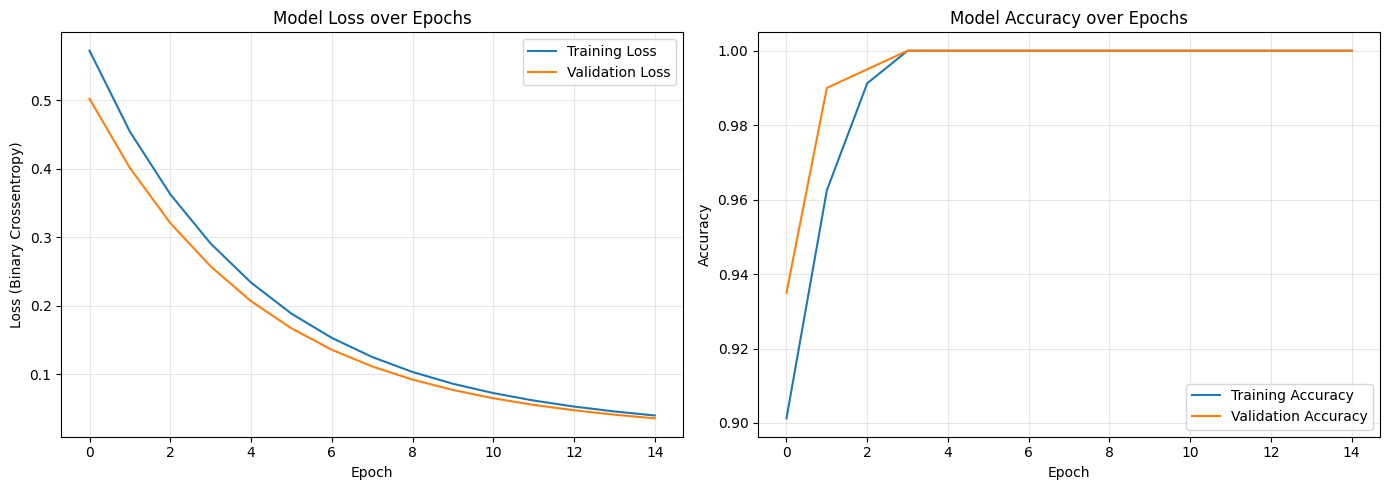

In [11]:
# 8. Visualize training history (Loss & Accuracy curves)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(history.history['loss'], label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title('Model Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (Binary Crossentropy)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curve
axes[1].plot(history.history['accuracy'], label='Training Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_title('Model Accuracy over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Visualize Model Evaluation (Confusion Matrix & ROC Curve)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


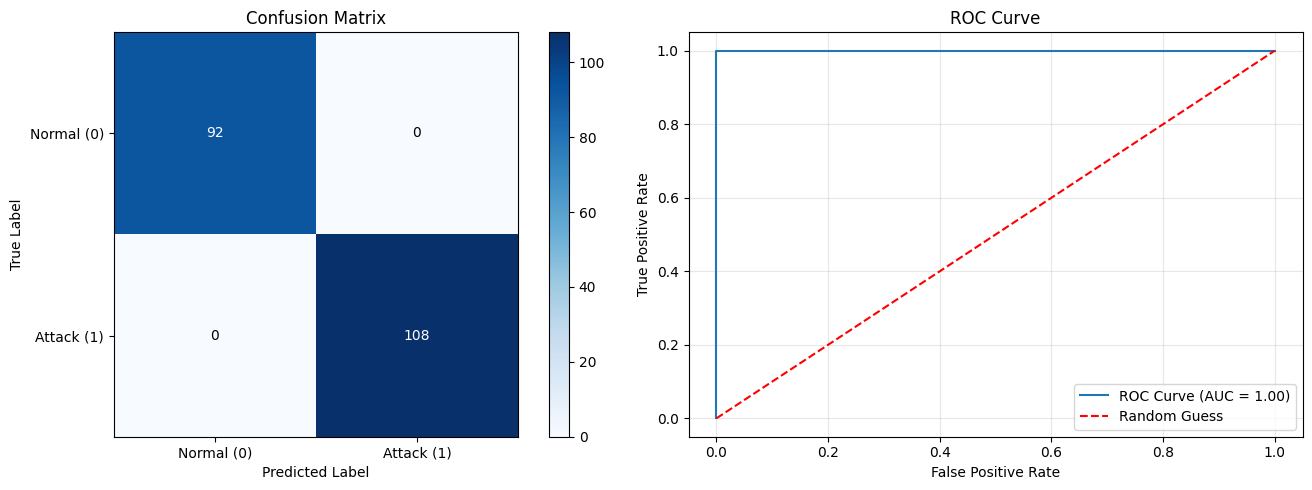

In [12]:
# 9. Evaluate on the test set: Confusion Matrix and ROC Curve
y_pred_prob = model.predict(X_test_scaled).flatten()
y_pred_class = (y_pred_prob > 0.5).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_class)
im = axes[0].imshow(cm, cmap='Blues')
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Normal (0)', 'Attack (1)'])
axes[0].set_yticklabels(['Normal (0)', 'Attack (1)'])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        axes[0].text(j, i, str(cm[i, j]), ha='center', va='center',
                      color='white' if cm[i, j] > cm.max() / 2 else 'black')
fig.colorbar(im, ax=axes[0])

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
axes[1].plot([0, 1], [0, 1], 'r--', label='Random Guess')
axes[1].set_title('ROC Curve')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
# 7. Test it with a fake "Live" Network Packet
print("\n--- SIMULATING LIVE TRAFFIC ---")

live_packet = pd.DataFrame({'duration': [12.5], 'src_bytes': [4500], 'dst_bytes': [40], 'failed_logins': [3]})

# We MUST scale the live data using the same scaler we used for training
live_packet_scaled = scaler.transform(live_packet)

prediction = model.predict(live_packet_scaled)
probability = prediction[0][0]

print(f"Attack Probability: {probability * 100:.2f}%")
if probability > 0.5:
    print(" ALERT: INTRUSION DETECTED! ")
else:
    print(" Traffic looks normal.")


--- SIMULATING LIVE TRAFFIC ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
Attack Probability: 98.20%
 ALERT: INTRUSION DETECTED! 


By SandarSingh

เเหล่งอ้างอิง : https://github.com/sandarsingh/Network-Intrusion-Classification---by-Sandar.git